In [2]:
pip install tensorflow matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

In [3]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step 
Training Data: (60000, 28, 28)
Testing Data: (10000, 28, 28)


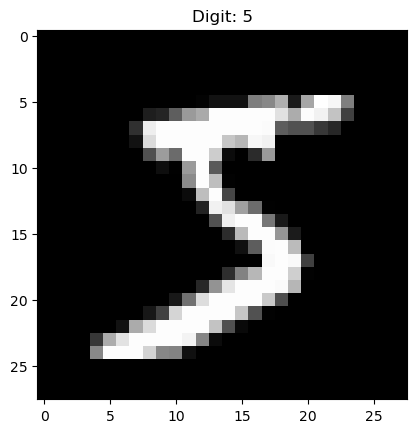

In [5]:
plt.imshow(X_train[0], cmap='gray')
plt.title("Digit: {}".format(y_train[0]))
plt.show()

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0
print("Normalization Complete")

Normalization Complete


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()

C:\Users\kamba\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model Compiled Successfully")

Model Compiled Successfully


In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9245 - loss: 0.2610 - val_accuracy: 0.9620 - val_loss: 0.1343
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9654 - loss: 0.1158 - val_accuracy: 0.9703 - val_loss: 0.1003
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9764 - loss: 0.0792 - val_accuracy: 0.9755 - val_loss: 0.0810
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9816 - loss: 0.0602 - val_accuracy: 0.9752 - val_loss: 0.0808
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9858 - loss: 0.0475 - val_accuracy: 0.9686 - val_loss: 0.0966


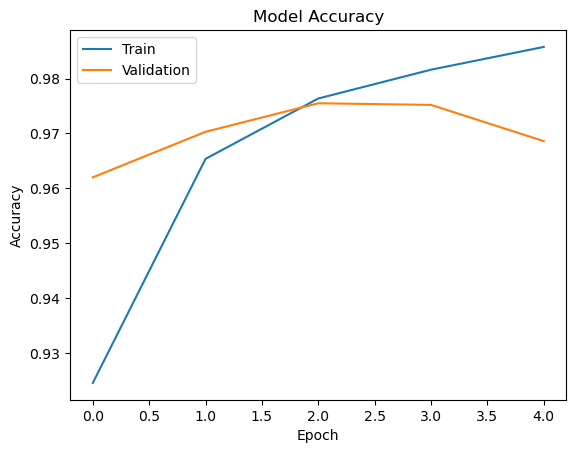

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.show()

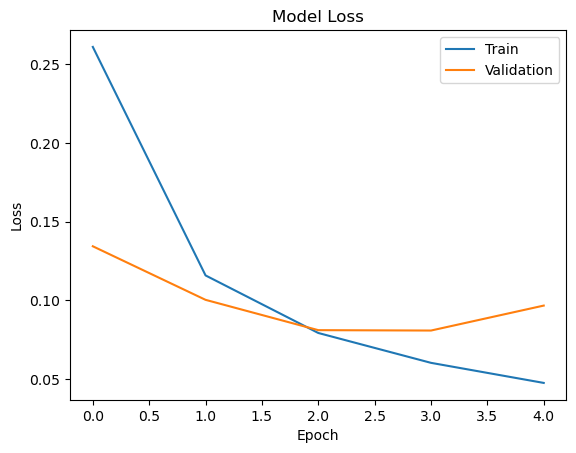

In [11]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.show()

In [12]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9686 - loss: 0.0966
Accuracy: 0.9685999751091003


In [13]:
model.save("digit_classifier_model.h5")
print("Model Saved Successfully")

Model Saved Successfully


In [14]:
prediction = model.predict(X_test[:1])
import numpy as np
print("Predicted Digit:", np.argmax(prediction))
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Predicted Digit: 7
Actual Digit: 7


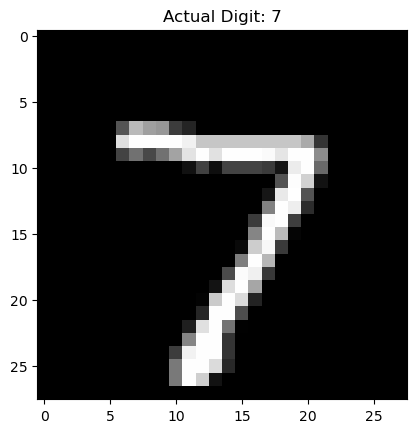

In [15]:
plt.imshow(X_test[0], cmap='gray')
plt.title("Actual Digit: {}".format(y_test[0]))
plt.show()

In [16]:
for i in range(3):
    prediction = model.predict(X_test[i:i+1], verbose=0)
    print("Image", i)
    print("Predicted:", np.argmax(prediction))
    print("Actual:", y_test[i])
    print("----------------")

Image 0
Predicted: 7
Actual: 7
----------------
Image 1
Predicted: 2
Actual: 2
----------------
Image 2
Predicted: 1
Actual: 1
----------------
